In [ ]:
%%capture
! pip install laspy 

In [108]:
# Geospatial and mapping libraries
import geopandas as gpd

# LAS (LiDAR) file handling
import laspy
from laspy import read

# Data analysis and manipulation
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Warnings management
import warnings
import os

In [6]:
def load_and_filter_las(file_path: str, filter_class: int = 5) -> np.ndarray:
    """
    Load a .las file and return points filtered by classification.
    """
    try:
        las = laspy.read(file_path)
        mask = las.classification == filter_class
        points = np.stack([las.x[mask], las.y[mask], las.z[mask]], axis=1)
        return points
    except Exception as e:
        print(f"Error loading and filtering file: {e}")
        return None


In [114]:
def plot_normalized_lidar(lidar_file: str):
    """
    Plot a 3D LiDAR point cloud with ground points in red and normalized coordinates.
    """
    try:
        las = laspy.read(lidar_file)
        points = np.stack([las.x, las.y, las.z], axis=1)
        classifications = las.classification

        # Normalize points to start from (0, 0, 0)
        points -= points.min(axis=0, keepdims=True)

        ground_mask = classifications == 2
        ground_points = points[ground_mask]
        other_points = points[~ground_mask]

        file_name = os.path.splitext(os.path.basename(lidar_file))[0]

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="3d")

        ax.scatter(
            ground_points[:, 0],
            ground_points[:, 1],
            ground_points[:, 2],
            c="red",
            s=0.5,
            label="Ground Points",
        )

        ax.scatter(
            other_points[:, 0],
            other_points[:, 1],
            other_points[:, 2],
            c=other_points[:, 2],
            cmap="viridis",
            s=0.5,
        )

        ax.set_title("LiDAR Point Cloud Visualization (Normalized)")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")  

        ax.view_init(elev=30, azim=45)  
        ax.legend(loc="upper right", markerscale=5, fontsize=10)

        plt.figtext(0.5, 0.01, f"{file_name}", ha="center", style="italic")

        plt.show()

    except Exception as e:
        print(f"Error visualizing LiDAR file: {e}")


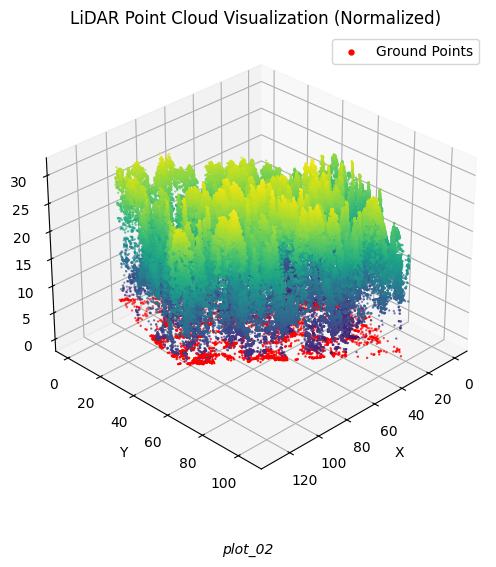

In [115]:
plot_normalized_lidar("../data/als/plot_02.las")

In [1]:
from utils import read_lidar_to_df


lidar_df_1 = read_lidar_to_df("../data/als/plot_01.las")
lidar_df_2 = read_lidar_to_df("../data/als/plot_02.las")
lidar_df_3 = read_lidar_to_df("../data/als/plot_03.las")
lidar_df_4 = read_lidar_to_df("../data/als/plot_04.las")
lidar_df_5 = read_lidar_to_df("../data/als/plot_05.las")
lidar_df_6 = read_lidar_to_df("../data/als/plot_06.las")
lidar_df_7 = read_lidar_to_df("../data/als/plot_07.las")
lidar_df_8 = read_lidar_to_df("../data/als/plot_08.las")
lidar_df_9 = read_lidar_to_df("../data/als/plot_09.las")
lidar_df_10 = read_lidar_to_df("../data/als/plot_10.las")


print(lidar_df_1.classification.value_counts())
print(lidar_df_2.classification.value_counts())
print(lidar_df_3.classification.value_counts())
print(lidar_df_4.classification.value_counts())
print(lidar_df_5.classification.value_counts())
print(lidar_df_6.classification.value_counts())
print(lidar_df_7.classification.value_counts())
print(lidar_df_8.classification.value_counts())
print(lidar_df_9.classification.value_counts())
print(lidar_df_10.classification.value_counts())


classification
5.0    213993
2.0      4880
Name: count, dtype: int64
classification
5.0    350098
2.0      5501
Name: count, dtype: int64
classification
5.0    296168
2.0      5388
Name: count, dtype: int64
classification
5.0    241722
2.0      9529
Name: count, dtype: int64
classification
5.0    98878
2.0     6893
Name: count, dtype: int64
classification
5.0    288921
2.0      8885
Name: count, dtype: int64
classification
5.0    305722
2.0      6989
Name: count, dtype: int64
classification
5.0    255654
2.0     13259
Name: count, dtype: int64
classification
5.0    302378
2.0     10136
Name: count, dtype: int64
classification
5.0    311011
2.0      3177
Name: count, dtype: int64
